In [1]:
import bisect
from collections import defaultdict
import gzip
import h5py
import logomaker
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import scipy.stats
from sklearn.neighbors import KernelDensity

from motif_llr_scoring import *

%matplotlib inline

## Specify paths
- `positive_data_path`: path to bedfile of positive sequences used for DeepLIFT
- `deeplift_outputs_dir`: directory containing outputs of DeepLIFT (`attributions.npz`, `encodings.npz`)
- `modisco_outputs_dir`: directory containing outputs of TF-MoDISco (modisco-lite)
- `shape_h5_path`: path to hdf5 file containing genome shape features
- `chip_file_path`: path to ChIP-seq bedfile for target of interest

In [2]:
positive_data_path = /ABSOLUTE/PATH/data/HepG2_MafK/positive_data.bed
deeplift_outputs_dir = "outputs"
modisco_outputs_dir = "outputs/modisco"
shape_h5_path = /path/to/hg19.EP_HelT_MGW_ProT_Roll.hdf5
chip_file_path = /ABSOLUTE/PATH/data/HepG2_MafK/wgEncodeAwgTfbsSydhHepg2Mafkab50322IggrabUniPk.narrowPeak.gz"

## Load genomics shape features and ChIP-seq data

In [3]:
feats = ["EP", "HelT", "MGW", "ProT", "Roll"]
shape_h5 = h5py.File(shape_h5_path)
shape_stats = shape_h5['stats']

chip_df = pd.read_csv(chip_file_path, sep='\t', header=None)
print(chip_df.head())
chip_intervals = [tuple(row[1][:3]) for row in chip_df.iterrows()]

       0          1          2  3     4  5           6  7         8    9
0   chr2  136763100  136763356  .  1000  .  634.618391 -1  4.430704  138
1   chr7    7139316    7139603  .  1000  .  634.276748 -1  4.430704  140
2  chr18    3723210    3723484  .  1000  .  632.716957 -1  4.430704  138
3  chr14   22456264   22456522  .  1000  .  630.459106 -1  4.430704  114
4   chr3  132726482  132726751  .  1000  .  627.107234 -1  4.430704  143


## Helper functions for plotting

In [4]:
def get_shape_pattern_from_seqlets_h5_and_atts(seqlets, feat_i, atts, encodings):
    """Gets shape pattern by averaging actual shape values at occurrences of the shape motif."""
    n_seqlets = seqlets['n_seqlets'][0]
    shape_alignment = []
    att_alignment = []
    for i in range(n_seqlets):
        ex_i = seqlets['example_idx'][i]
        start = seqlets['start'][i]
        end = seqlets['end'][i]
        is_revcomp = seqlets['is_revcomp'][i]
        att = atts[ex_i, 4+feat_i, 300 + start:300 + end]
        shape = encodings[ex_i, 4+feat_i, 300+start:300+end]
        if is_revcomp:
            att = att[::-1]
            shape = shape[::-1]
        att_alignment.append(att)
        shape_alignment.append(shape)
    shape_alignment = np.array(shape_alignment)
    att_alignment = np.array(att_alignment)
    return (shape_alignment.mean(axis=0),
            shape_alignment.std(axis=0),
            att_alignment.mean(axis=0),
            shape_alignment)

def plot_shape_pattern(shpat, std, att, feat, smin, smax, ax, verbose=True):
    x = np.arange(len(shpat))
    if feat in ['HelT', 'Roll']:
        x = x - 0.5
    normed_att = att / np.abs(att).max()
    total_att = att.sum()
    std = std*(smax - smin)
    shpat = shpat*(smax - smin) + smin
    ax.plot(x, shpat)
    ax.scatter(x, shpat, s=75, c=plt.cm.bwr(normed_att / 2 + 0.5))
    ax.fill_between(x, shpat - std, shpat + std, alpha=0.3)
    featspan = smax - smin
    ax.set_ylim(smin - 0.05*featspan, smax + 0.05*featspan)
    ax.tick_params(labelsize=16)
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    if verbose:
        ax.text(0.02, 0.85, f"{feat}, mean total {feat} att={total_att:.4f}",
                transform=ax.transAxes, fontsize=16)
        ax.scatter([0.91], [0.89], s=100, c=plt.cm.bwr([0.99]), transform=ax.transAxes)
        ax.text(0.925, 0.85, f"{np.abs(att).max():.5f}", ha='left', fontsize=16, transform=ax.transAxes)
    else:
        ax.set_xticks([])
        
    
def get_hlint(att, k=1):
    where_lit = np.where(att > att.mean() + k*att.std())[0]
    if len(where_lit) == 0:
        return (0, 0)
    return np.min(where_lit), np.max(where_lit) + 1

def highlight(att, ax, feat):
    hlint = get_hlint(att)
    min_lit, max_lit = hlint
    if feat in ['HelT', 'Roll']:
        min_lit, max_lit = min_lit - 0.5, max_lit - 0.5
    ax.axvspan(min_lit - 0.5, max_lit - 0.5, alpha=0.3, color='yellow')
    return hlint

## Choose a pair of sequence and shape motifs

Num shape occurrences: 1773
Num seq occurrences: 4116


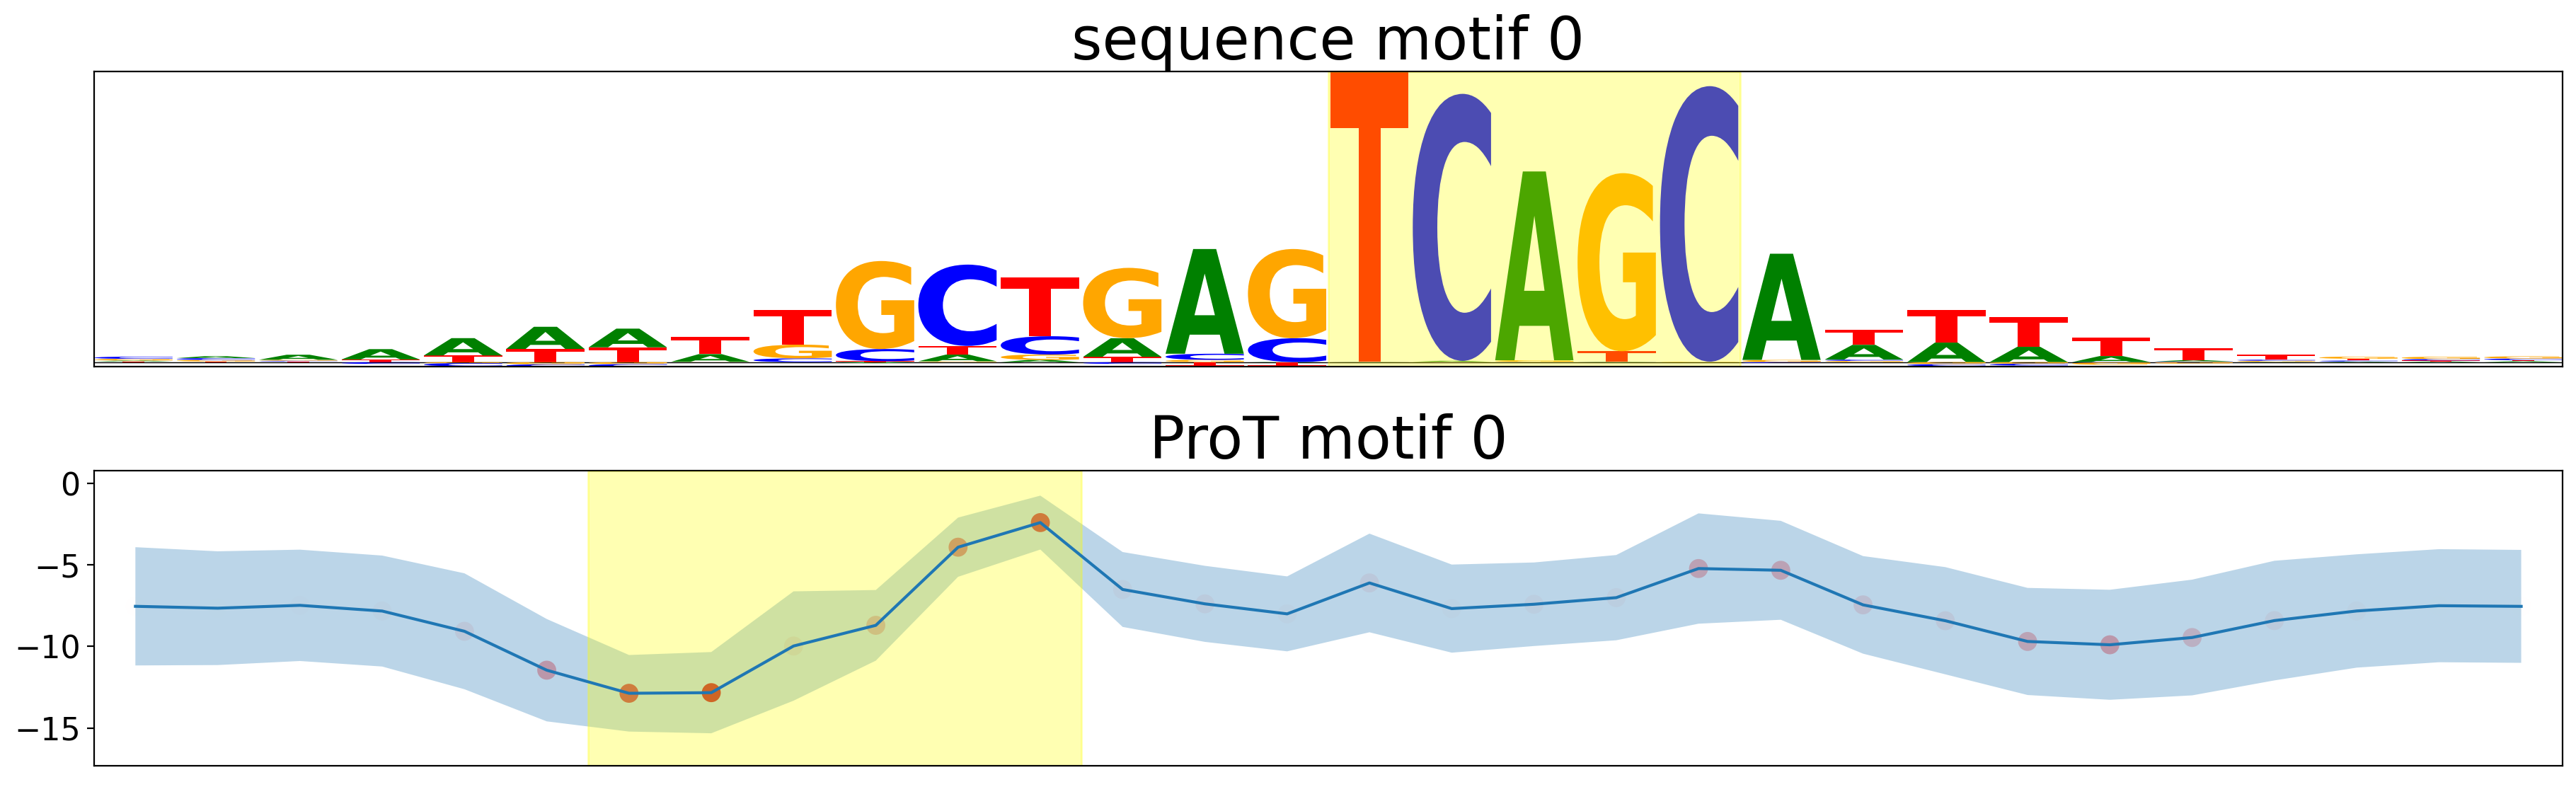

In [5]:
feat, shape_pat_i = 'ProT', 0
seq_pat_i = 0

fi = feats.index(feat)
smin, smax = shape_stats[fi, 1:3]

shape_h5 = h5py.File(f"{modisco_outputs_dir}/{feat}_results.h5")
seq_h5 = h5py.File(f"{modisco_outputs_dir}/seq_results.h5")

atts = np.load(f"{deeplift_outputs_dir}/attributions.npz")['arr_0']
encodings = np.load(f"{deeplift_outputs_dir}/encodings.npz")['arr_0']

shpat_h5 = shape_h5['pos_patterns'][f"pattern_{shape_pat_i}"]
shpat, std, att, shape_alignment = \
    get_shape_pattern_from_seqlets_h5_and_atts(shpat_h5['seqlets'], fi, atts, encodings)

sepat_h5 = seq_h5['pos_patterns'][f"pattern_{seq_pat_i}"]
sepat = sepat_h5['contrib_scores'][:]

shhlint = get_hlint(att)
sehlint = get_hlint(sepat.sum(axis=1))

print(f"Num shape occurrences: {shpat_h5['seqlets']['n_seqlets'][0]}")
print(f"Num seq occurrences: {sepat_h5['seqlets']['n_seqlets'][0]}")

fig, axes = plt.subplots(2, 1, figsize=(22.5, 6.5), gridspec_kw={'hspace': 0.35}, dpi=200)
fig.patch.set_alpha(0.0)
ax = axes[0]
logo_df = pd.DataFrame(sepat, columns=['A', 'C', 'G', 'T'])
logomaker.Logo(logo_df, ax=ax)
ax.set_title(f"sequence motif {seq_pat_i}", fontsize=30)
ax.set_xticks([])
ax.set_yticks([])
ax.axvspan(sehlint[0]-0.5, sehlint[1]-0.5, color='yellow', alpha=0.3)

ax = axes[1]
plot_shape_pattern(shpat, std, att, feat, smin, smax, ax, verbose=False)
ax.set_title(f"{feat} motif {shape_pat_i}", fontsize=30)
ax.axvspan(shhlint[0] - 0.5, shhlint[1] - 0.5, color='yellow', alpha=0.3)
plt.show()

## Convert to standard motifs

helper functions

In [6]:
bandwidths = {"EP": 0.035, "HelT": 0.04, "MGW": 0.04, "ProT": 0.04, "Roll": 0.05}
def shape_motif_kde(shape_alignment, feat, grid_size=40):
    """Computes a kernel density estimator which estimates the density
    of the shape motif at each position, using the aligned seqlets.
    
    Parameters
    ----------
    shape_alignment: (n_seqlets, L) array of shape seqlets
    feat: string, one of ["EP", "HelT", "MGW", "ProT", "Roll"]
    grid_size: int

    Returns
    -------
    kde_grid: (grid_size,) array of feat. vals to sample scores at
    kde_scores: (L, grid_size) array of per-position scores
    """
    L = shape_alignment.shape[1]
    kde_grid = np.linspace(-0.05, 1.05, grid_size)
    kde_scores = np.zeros((L, grid_size))
    for i in range(L):
        kde = KernelDensity(bandwidth=bandwidths[feat], kernel='gaussian')
        kde.fit(np.random.permutation(shape_alignment[:, i])[:1000, None])
        kde_scores[i] = kde.score_samples(kde_grid[:, None])
    return kde_grid, kde_scores

seq_bg_freqs = np.array([0.273, 0.227, 0.227, 0.273])
def get_ppm(seq_pattern_h5):
    ppm = seq_pattern_h5['sequence'][:] # (L, 4)
    ppm += 4*seq_bg_freqs / seq_pattern_h5['seqlets']['n_seqlets'][0] # pseudocount
    ppm = ppm / ppm.sum(axis=1, keepdims=True)
    return ppm

def get_pwm(ppm): return np.log(ppm) - np.log(seq_bg_freqs)

def get_icm(seq_pattern_h5):
    ppm = get_ppm(seq_pattern_h5)
    pwm = get_pwm(ppm)
    return ppm*(ppm*pwm).sum(axis=1, keepdims=True)

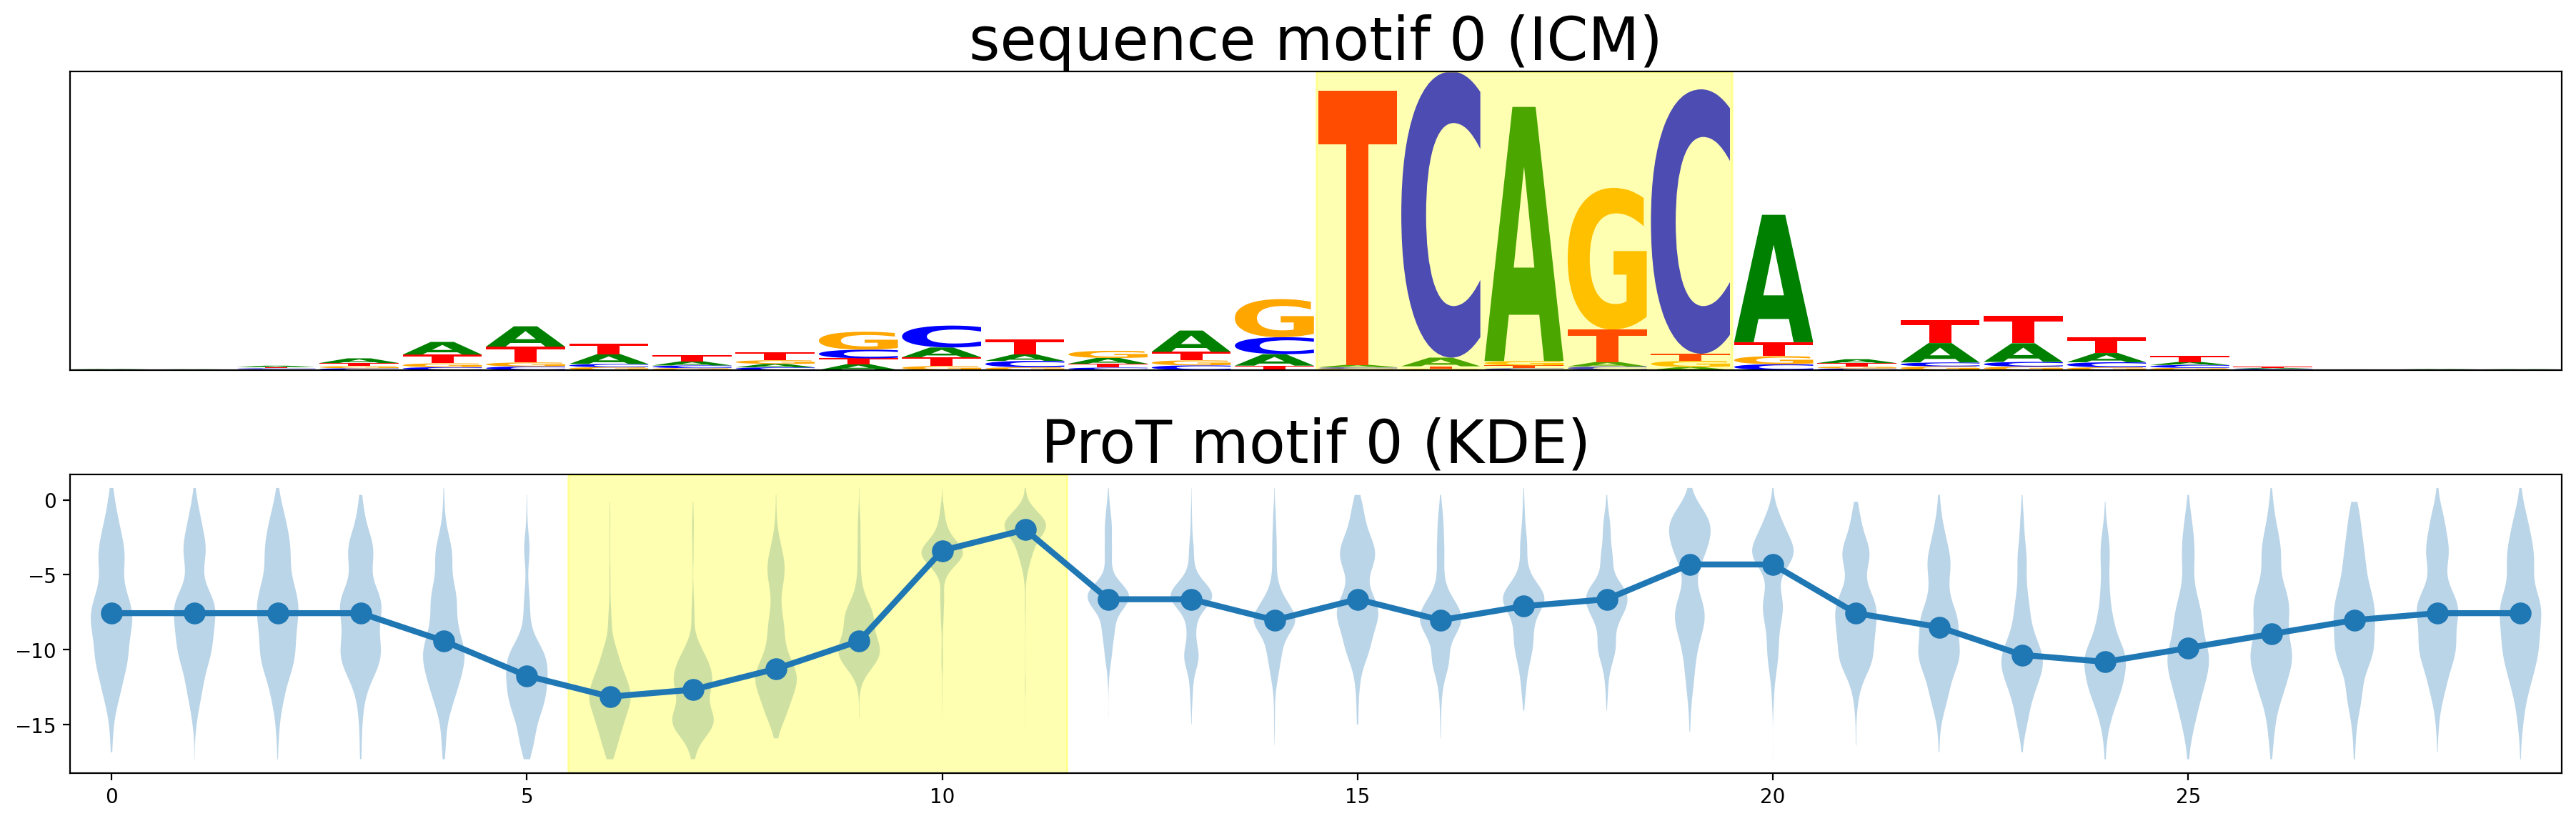

In [7]:
kde_grid, kde_scores = shape_motif_kde(shape_alignment, feat)
icm = get_icm(sepat_h5)

fig, axes = plt.subplots(2, 1, figsize=(22.5, 6.5), gridspec_kw={'hspace': 0.35}, dpi=200)
fig.patch.set_alpha(0.0)
ax = axes[0]
logo_df = pd.DataFrame(icm, columns=['A', 'C', 'G', 'T'])
logomaker.Logo(logo_df, ax=ax)
ax.set_title(f"sequence motif {seq_pat_i} (ICM)", fontsize=30)
ax.set_xticks([])
ax.set_yticks([])
ax.axvspan(sehlint[0]-0.5, sehlint[1]-0.5, color='yellow', alpha=0.3)

# simulate data sampled from the shape motif density at each position
# in order to generate violin plots
def make_simulated_data(kde_grid, kde_scores, size=1000):
    p = np.exp(kde_scores)
    p = p / p.sum()
    return np.random.choice(kde_grid, size=size, p=p)
simulated_datas = []
for i, kde_scores_i in enumerate(kde_scores):
    simulated_datas.append(make_simulated_data(kde_grid, kde_scores_i) * (smax - smin) + smin)
mids = [np.median(x) for x in simulated_datas]
ax = axes[1]
motif_len = len(kde_scores)
ax.violinplot(simulated_datas, positions=range(motif_len), showextrema=False)
ax.plot(range(motif_len), mids, '-C0o', markersize=10, linewidth=3)
ax.set_xlim(-0.5, motif_len - 0.5)
ylim = ax.get_ylim()
ax.set_ylim(min(ylim[0], smin), max(ylim[1], smax))
ax.set_title(f"{feat} motif {shape_pat_i} (KDE)", fontsize=30)
ax.axvspan(shhlint[0] - 0.5, shhlint[1] - 0.5, color='yellow', alpha=0.3)

plt.show()

## Find co-occurrences of chosen pair of motifs

In [8]:
ppm = get_ppm(sepat_h5)
pwm = get_pwm(ppm)
print(f"pwm.shape: {pwm.shape}")

grid_size = 40
feat_i = feats.index(feat)
background_shape_vals = encodings[:, 4+feat_i].flatten()
background_kde_grid, background_kde_scores = \
    shape_motif_kde(background_shape_vals[:, None], feat, grid_size=40)
background_kde_scores = background_kde_scores[0]

print(f"kde_grid.shape: {kde_grid.shape}")
print(f"kde_scores.shape: {kde_scores.shape}")
print(f"background_kde_grid.shape: {background_kde_grid.shape}")
print(f"background_kde_scores.shape: {background_kde_scores.shape}")

pwm.shape: (30, 4)
kde_grid.shape: (40,)
kde_scores.shape: (30, 40)
background_kde_grid.shape: (40,)
background_kde_scores.shape: (40,)


### Compute occurrence threshold for sequence and shape motif by looking at the distribution of scores among seqlets

seq_alignment.shape (4116, 4, 30)
shape_alignment.shape (1773, 30)
seq_seqlet_llrs.shape (2, 4116)
shape_seqlet_llrs.shape (2, 1773)
seq threshold 7.597581386566162
shape threshold 8.611577987670898


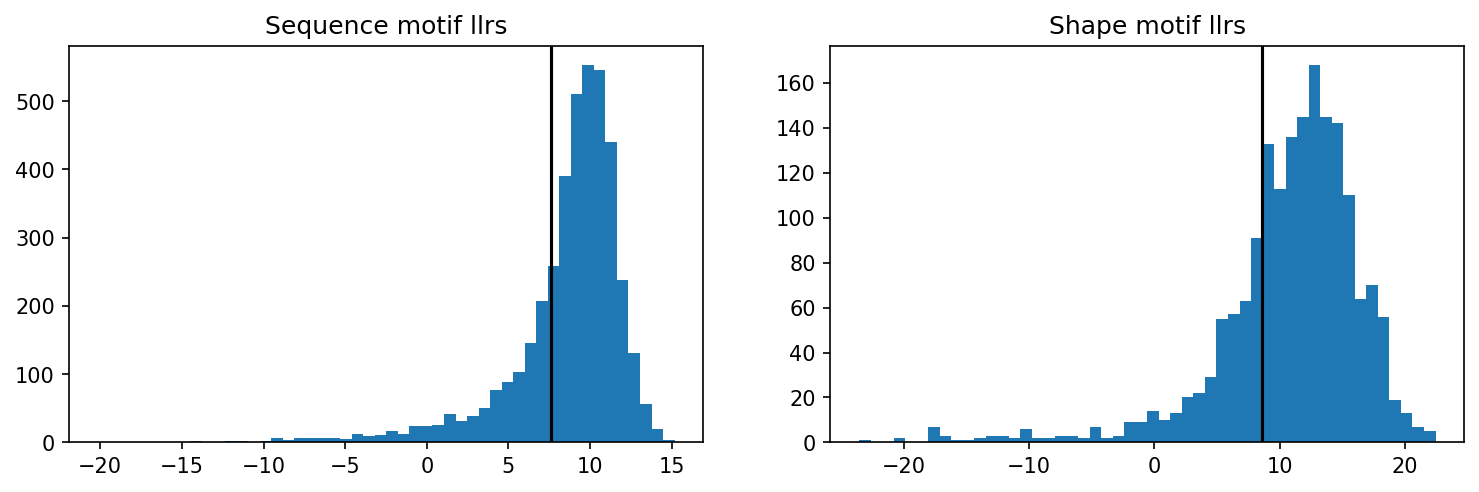

In [9]:
seq_alignment = sepat_h5['seqlets']['sequence'][:]
seq_alignment = seq_alignment.transpose(0, 2, 1)
print("seq_alignment.shape", seq_alignment.shape)
print("shape_alignment.shape", shape_alignment.shape)

seq_seqlet_llrs = compute_seq_motif_llrs(seq_alignment, pwm)

shape_seqlet_llrs = compute_shape_motif_llrs(
    shape_alignment, background_kde_grid, background_kde_scores,
    kde_grid, kde_scores
)

print("seq_seqlet_llrs.shape", seq_seqlet_llrs.shape)
print("shape_seqlet_llrs.shape", shape_seqlet_llrs.shape)

seq_threshold = np.quantile(seq_seqlet_llrs[0], 0.25)
shape_threshold = np.quantile(shape_seqlet_llrs[0], 0.25)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=150)
axes[0].hist(seq_seqlet_llrs[0], 50)
axes[0].set_title("Sequence motif llrs")
axes[0].axvline(seq_threshold, color='black')

axes[1].hist(shape_seqlet_llrs[0], 50)
axes[1].set_title("Shape motif llrs")
axes[1].axvline(shape_threshold, color='black')

print("seq threshold", seq_threshold)
print("shape threshold", shape_threshold)

plt.show()

### Call occurrences among encodings

In [10]:
center_atts = atts[:, :, 300:700]
center_encs = encodings[:, :, 300:700]

In [11]:
seq_llrs = compute_seq_motif_llrs(center_encs[:, :4], pwm)
shape_llrs = compute_shape_motif_llrs(
    center_encs[:, 4+feat_i], background_kde_grid, background_kde_scores,
    kde_grid, kde_scores
)

In [12]:
seq_occurrence_vecs = call_occurrences(seq_llrs, seq_threshold, interval=sehlint)
shape_occurrence_vecs = call_occurrences(shape_llrs, shape_threshold, interval=shhlint)

In [13]:
def get_occurrence_tuples(occurrence_vecs, hilited_interval):
    """From occurrence vectors, generates list of tuples.
    Parameters
    ----------
    occurrence_vecs : np.ndarray
        (2, n_seqs, n_positions)
    hilited_interval : tuple

    Returns
    -------
    list of tuples
        each entry is of form (idx, start, end, strand)
    """
    n = occurrence_vecs.shape[1]
    occurrences = []
    hl_start, hl_end = hilited_interval
    rev_hl_start, rev_hl_end = 30 - hl_end, 30 - hl_start
    for i in range(n):
        for pos in np.where(occurrence_vecs[0, i])[0]:
            occurrences.append((i, pos + hl_start, pos + hl_end, "+"))
        for pos in np.where(occurrence_vecs[1, i])[0]:
            occurrences.append((i, pos + rev_hl_start, pos + rev_hl_end, "-"))
    return occurrences

def get_occurrences_by_example_idx(occurrences):
    """Organizes occurrences by example index. Returns a dictionary
    where each key is an example index, and each value is the list of
    occurrence tuples coming from that example index.
    """
    occurrences_by_ex_idx = defaultdict(list)
    for occurrence in occurrences:
        example_idx = occurrence[0]
        occurrences_by_ex_idx[example_idx].append(occurrence)
    return occurrences_by_ex_idx

In [14]:
seq_occurrences = get_occurrence_tuples(seq_occurrence_vecs, sehlint)
seq_occs_by_ex_idx = get_occurrences_by_example_idx(seq_occurrences)
shape_occurrences = get_occurrence_tuples(shape_occurrence_vecs, shhlint)
shape_occs_by_ex_idx = get_occurrences_by_example_idx(shape_occurrences)

### Compute cooccurrences

Get co-occurring shape motif and sequence motif occurrences, based on whether they overlap or have closest endpoints within 5 bp of each other. The highlighted region of the motif is used to define the occurrence interval

In [15]:
def calc_iou(x1, y1, x2, y2):
    denom = max(1, max(y1, y2) - min(x1, x2))
    numer = max(0, min(y1, y2) - max(x1, x2))
    return numer / denom

def get_coocc_pairs(seq_occurrences, shape_occs_by_ex_idx, max_dist=5):
    pairs = []
    for seq_occurrence in seq_occurrences:
        example_idx, seq_occ_start, seq_occ_end = seq_occurrence[:3]
        if example_idx not in shape_occs_by_ex_idx:
            continue
        ious = []
        candidate_pairs = []
        for shape_occurrence in shape_occs_by_ex_idx[example_idx]:
            shape_occ_start, shape_occ_end = shape_occurrence[1:3]
            iou = calc_iou(seq_occ_start, seq_occ_end,
                           shape_occ_start, shape_occ_end)
            if (iou > 0 or np.abs(seq_occ_end - shape_occ_start) < max_dist
                    or np.abs(shape_occ_end - seq_occ_start) < max_dist):
                candidate_pairs.append((seq_occurrence, shape_occurrence))
                ious.append(iou)
        if len(ious) > 0:
            iou_argmax = np.argmax(ious)
            pairs.append(candidate_pairs[iou_argmax])
    return pairs
    
pairs = get_coocc_pairs(seq_occurrences, shape_occs_by_ex_idx)
print(f"Num shape occurrences: {len(shape_occurrences)}")
print(f"Num seq occurrences: {len(seq_occurrences)}")
print(f"Num pairs: {len(pairs)}")

Num shape occurrences: 11090
Num seq occurrences: 4436
Num pairs: 2978


restrict to co-occurrences with high similarity to the sequence motif

In [16]:
seq_occurrence_contribs = []
hl_start, hl_end = sehlint
rev_hl_start, rev_hl_end = 30 - hl_end, 30 - hl_start
seq_encs_x_atts = center_encs[:, :4] * center_atts[:, :4].sum(axis=1, keepdims=True)
for example_idx, start, end, strand in seq_occurrences:
    if strand == "+":
        start = start - hl_start
        end = start + 30
        contribs_window = seq_encs_x_atts[example_idx, :4, start:end]
    else:
        start = start - rev_hl_start
        end = start + 30
        contribs_window = seq_encs_x_atts[example_idx, :4, start:end]
        contribs_window = np.flip(contribs_window, axis=[0, 1])
    seq_occurrence_contribs.append(contribs_window)
seq_occurrence_contribs = np.stack(seq_occurrence_contribs).transpose(0, 2, 1)
seq_occurrence_contribs.shape

(4436, 30, 4)

In [17]:
def get_high_sim_occurrence_inds(contribs, seq_pattern_h5, q_thresh=0.9):
    motif = seq_pattern_h5['contrib_scores'][:].flatten()
    pearsons = []
    for i in range(len(contribs)):
        pearsons.append(scipy.stats.pearsonr(motif, contribs[i].flatten())[0])
    threshold = np.quantile(pearsons, q_thresh)
    print(f"Pearson corr. threshold: {threshold}")
    return np.where(pearsons >= threshold)[0]

chosen_inds = get_high_sim_occurrence_inds(seq_occurrence_contribs, sepat_h5)
strong_seq_occurrences = [seq_occurrences[i] for i in chosen_inds]
strong_seq_pairs = [x for x in pairs if x[0] in strong_seq_occurrences]

Pearson corr. threshold: 0.9250014684916721


## Plot co-occurrences / non-co-occurrences

In [18]:
def plot_seqlet(interval, encodings, atts, fi, feats, smin, smax, axes, verbose=True):
    example_idx, start, end, strand = interval
    is_revcomp = strand == '-'
    shape_seq = encodings[example_idx, 4 + fi, start:end]
    shape_seq = shape_seq * (smax - smin) + smin
    shape_att = atts[example_idx, 4 + fi, start:end]
    seq = encodings[example_idx, :4, start:end]
    seq_att = atts[example_idx, :4, start:end]
    seq_contrib = seq*seq_att
    seq_contrib = seq_contrib.T
    if fi in [1, 4]:
        seq_contrib = seq_contrib[1:]
        shape_range = np.arange(len(shape_seq)) - 0.5
    else:
        shape_range = np.arange(len(shape_seq))
    if is_revcomp:
        shape_seq = shape_seq[::-1]
        shape_att = shape_att[::-1]
        seq_contrib = seq_contrib[::-1, ::-1]
    total_shape_att = shape_att.sum()
    total_seq_att = seq_att.sum()
    total_allshape_att = atts[example_idx, 4:, start:end].sum()
    logo_df = pd.DataFrame(seq_contrib, columns=['A', 'C', 'G', 'T'])
    logomaker.Logo(logo_df, ax=axes[1])
    
    axes[0].plot(shape_range, shape_seq)
    normed_shape_att = shape_att / np.abs(shape_att).max()
    axes[0].scatter(shape_range, shape_seq, s=62, c=plt.cm.bwr(normed_shape_att / 2 + 0.5))
    featspan = smax - smin
    axes[0].set_ylim(smin - 0.05*featspan, smax + 0.05*featspan)
    axes[0].tick_params(axis='both', labelsize=14, size=5)
    
    if verbose:
        axes[1].text(0.02, 0.83, f"total seq att={total_seq_att:.4f}", transform=axes[1].transAxes, fontsize=16)
        axes[0].text(0.02, 0.83, f"{feats[fi]}, total {feats[fi]} att={total_shape_att:.4f}, total shape att: {total_allshape_att:.4f}",
                     transform=axes[0].transAxes, fontsize=16)
        axes[0].scatter([0.91], [0.89], s=100, c=plt.cm.bwr([0.99]), transform=axes[0].transAxes)
        axes[0].text(0.925, 0.85, f"{np.abs(shape_att).max():.5f}", ha='left', fontsize=16, transform=axes[0].transAxes)
        axes[0].tick_params(axis='both', labelsize=14, size=5)
    else:
        axes[0].text(0.02, 0.83, f"{feats[fi]}", transform=axes[0].transAxes, fontsize=16)
        axes[1].set_yticks([])
        axes[1].set_xticks([])

Plot example co-occurrences

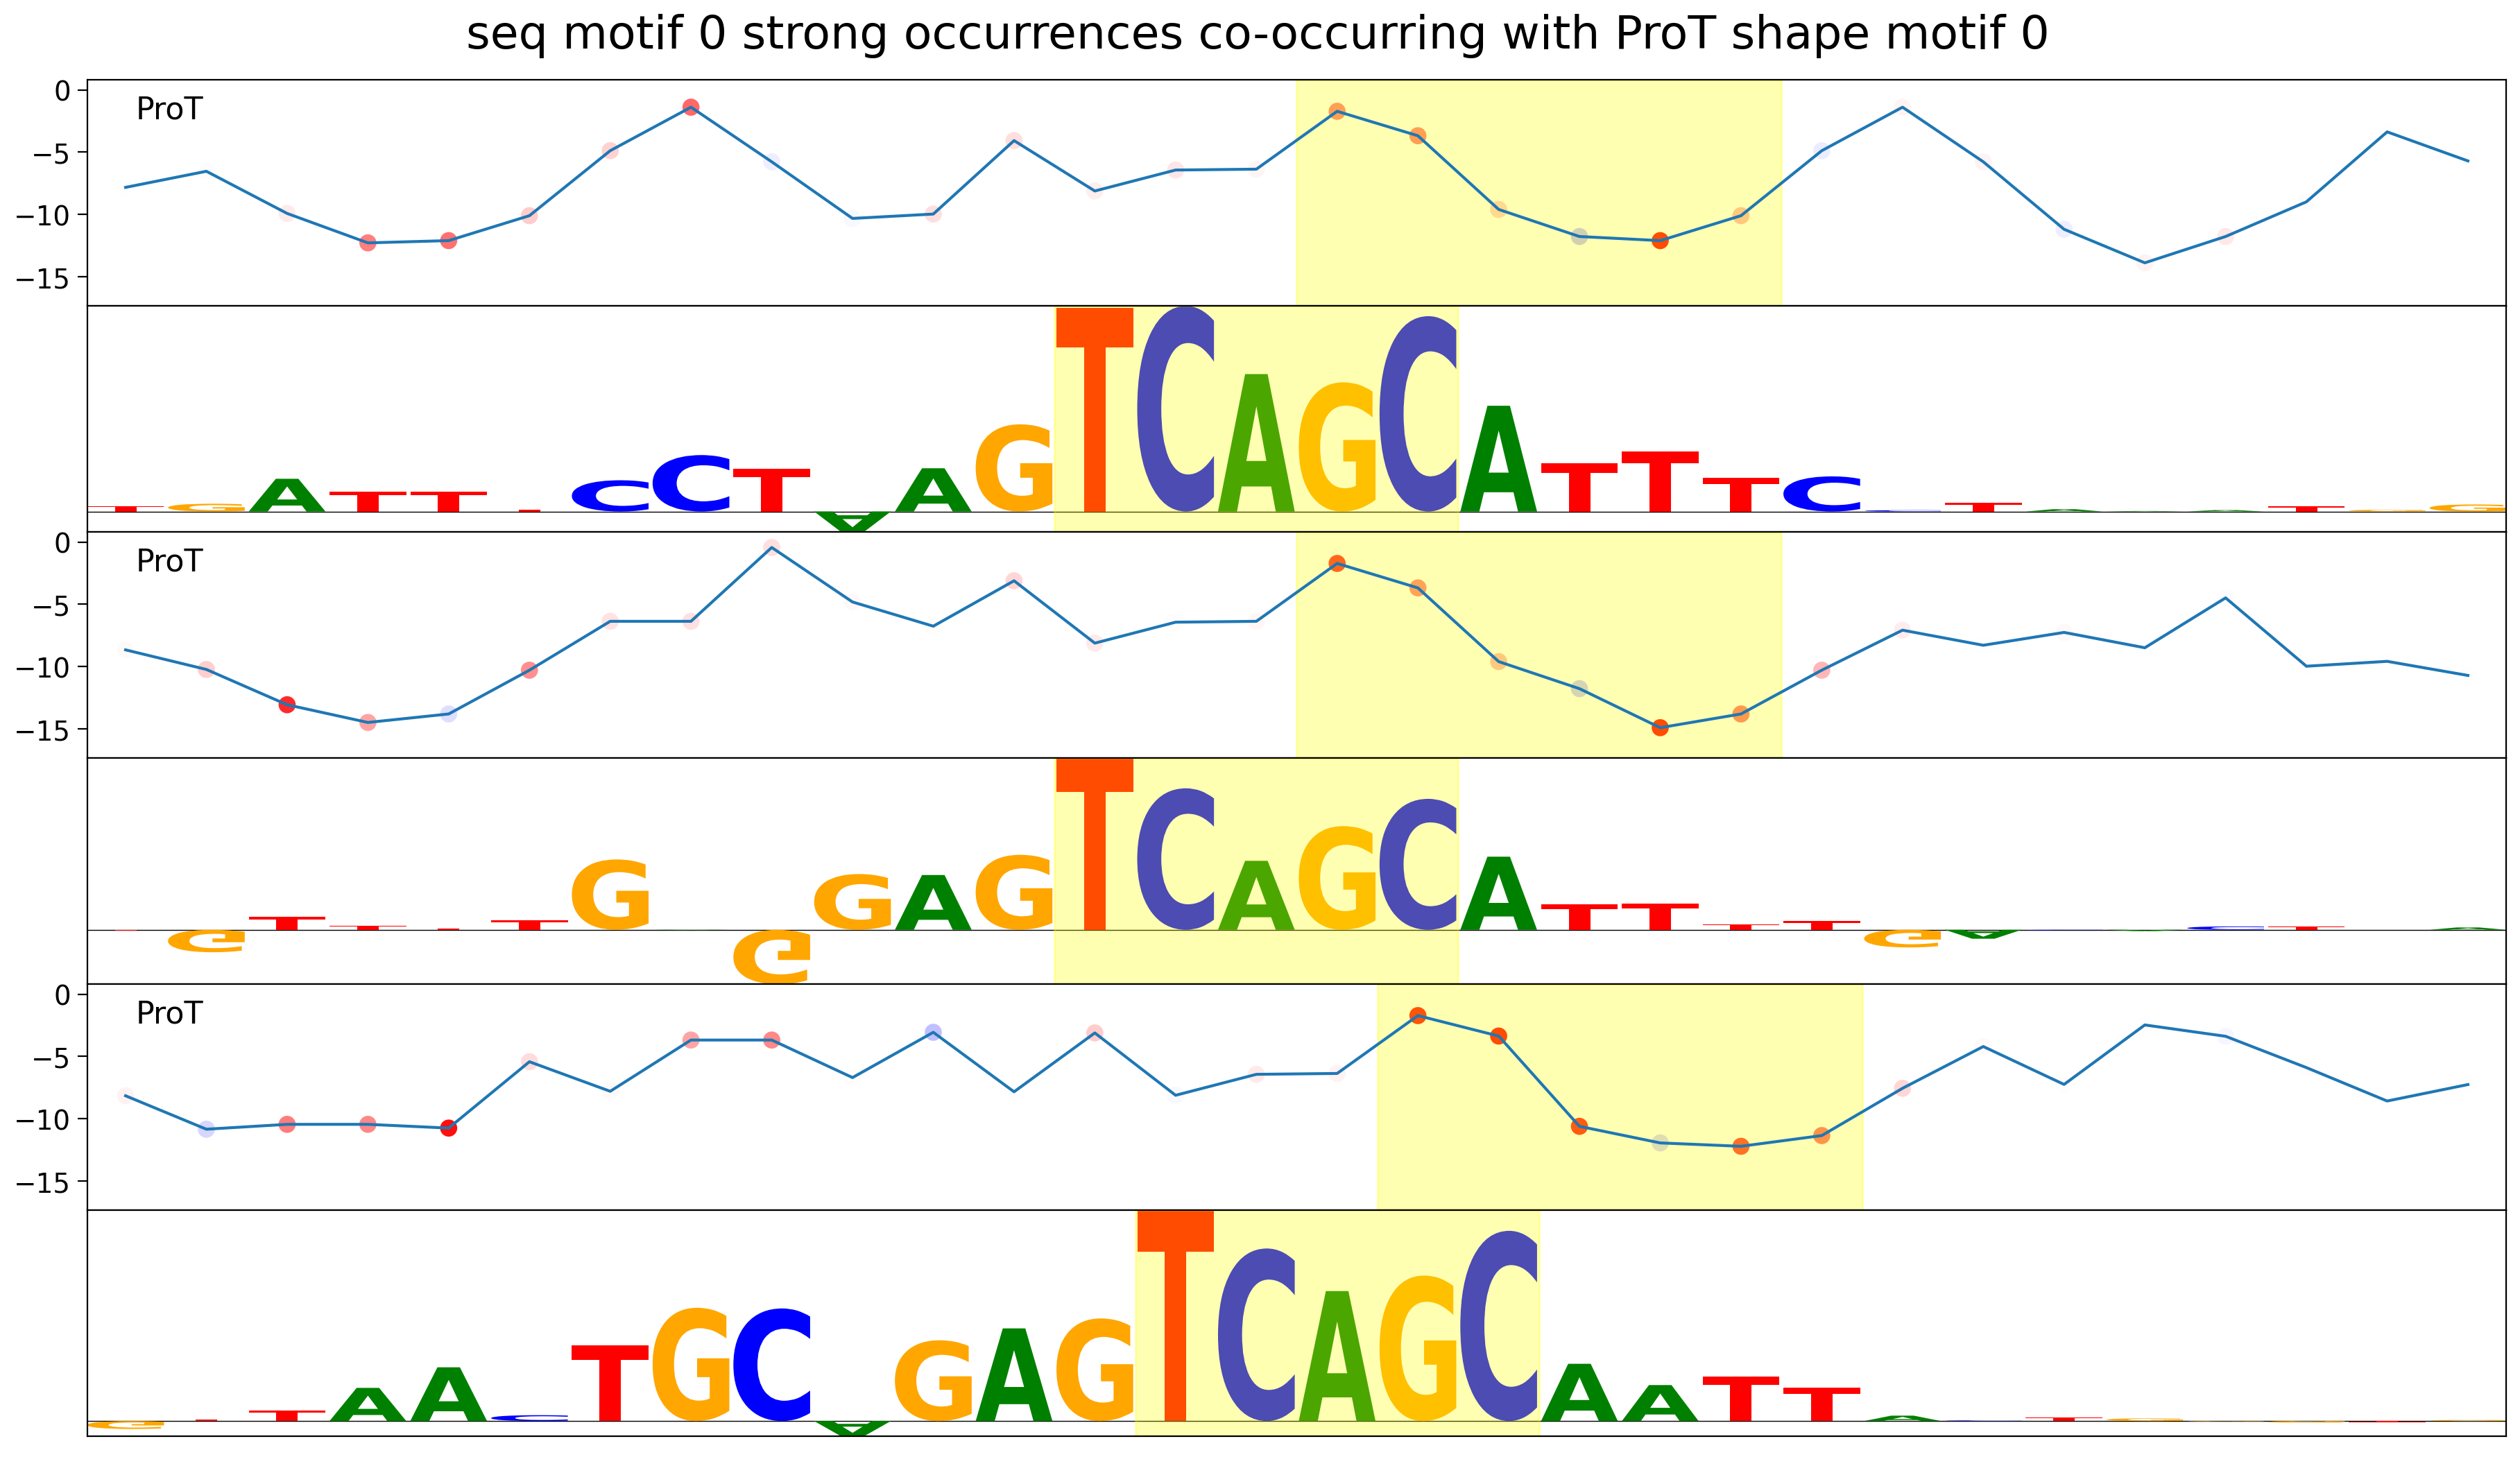

In [23]:
np.random.seed(251)
n_ex = 3
chosen_pair_inds = np.random.choice(len(strong_seq_pairs), n_ex, replace=False)
fig, axes = plt.subplots(2*n_ex, 1, figsize=(22.5, 2*2*n_ex), gridspec_kw={'hspace': 0}, sharex=True, dpi=200)
pairs_to_plot = [strong_seq_pairs[i] for i in chosen_pair_inds]
for i, pair in enumerate(pairs_to_plot):
    exi, start, end, strand = pair[0]
    mid = (start + end) // 2
    interval = (exi, mid - 15, mid + 15, strand)
    
    plot_seqlet(interval, center_encs, center_atts, fi, feats, smin, smax,
                axes[2*i:2*i+2], verbose=False)
    if strand == '+':
        rel_start = start - (mid - 15) - (fi in [1, 4])
        rel_end = end - (mid - 15) - (fi in [1, 4])
    else:
        rel_start = mid + 15 - end
        rel_end = mid + 15 - start
    axes[2*i + 1].axvspan(rel_start - 0.5, rel_end - 0.5, color='yellow', alpha=0.3)
    
    exi, start, end, _ = pair[1]
    if strand == '+':
        rel_start = max(start - (mid - 15) - (fi in [1, 4]), 0)
        rel_end = min(end - (mid - 15) - (fi in [1, 4]), 30)
    else:
        rel_start = max(mid + 15 - end, 0)
        rel_end = min(mid + 15 - start, 30)
    axes[2*i].axvspan(rel_start - 0.5, rel_end - 0.5, color='yellow', alpha=0.3)
fig.suptitle(f"seq motif {seq_pat_i} strong occurrences co-occurring with {feat} shape motif {shape_pat_i}",
            fontsize=24)
fig.subplots_adjust(top=0.94)

plt.show()
# plot examples of seq_pat_i that don't occur in pairs, along with shape feat

plot example non-co-occurrences

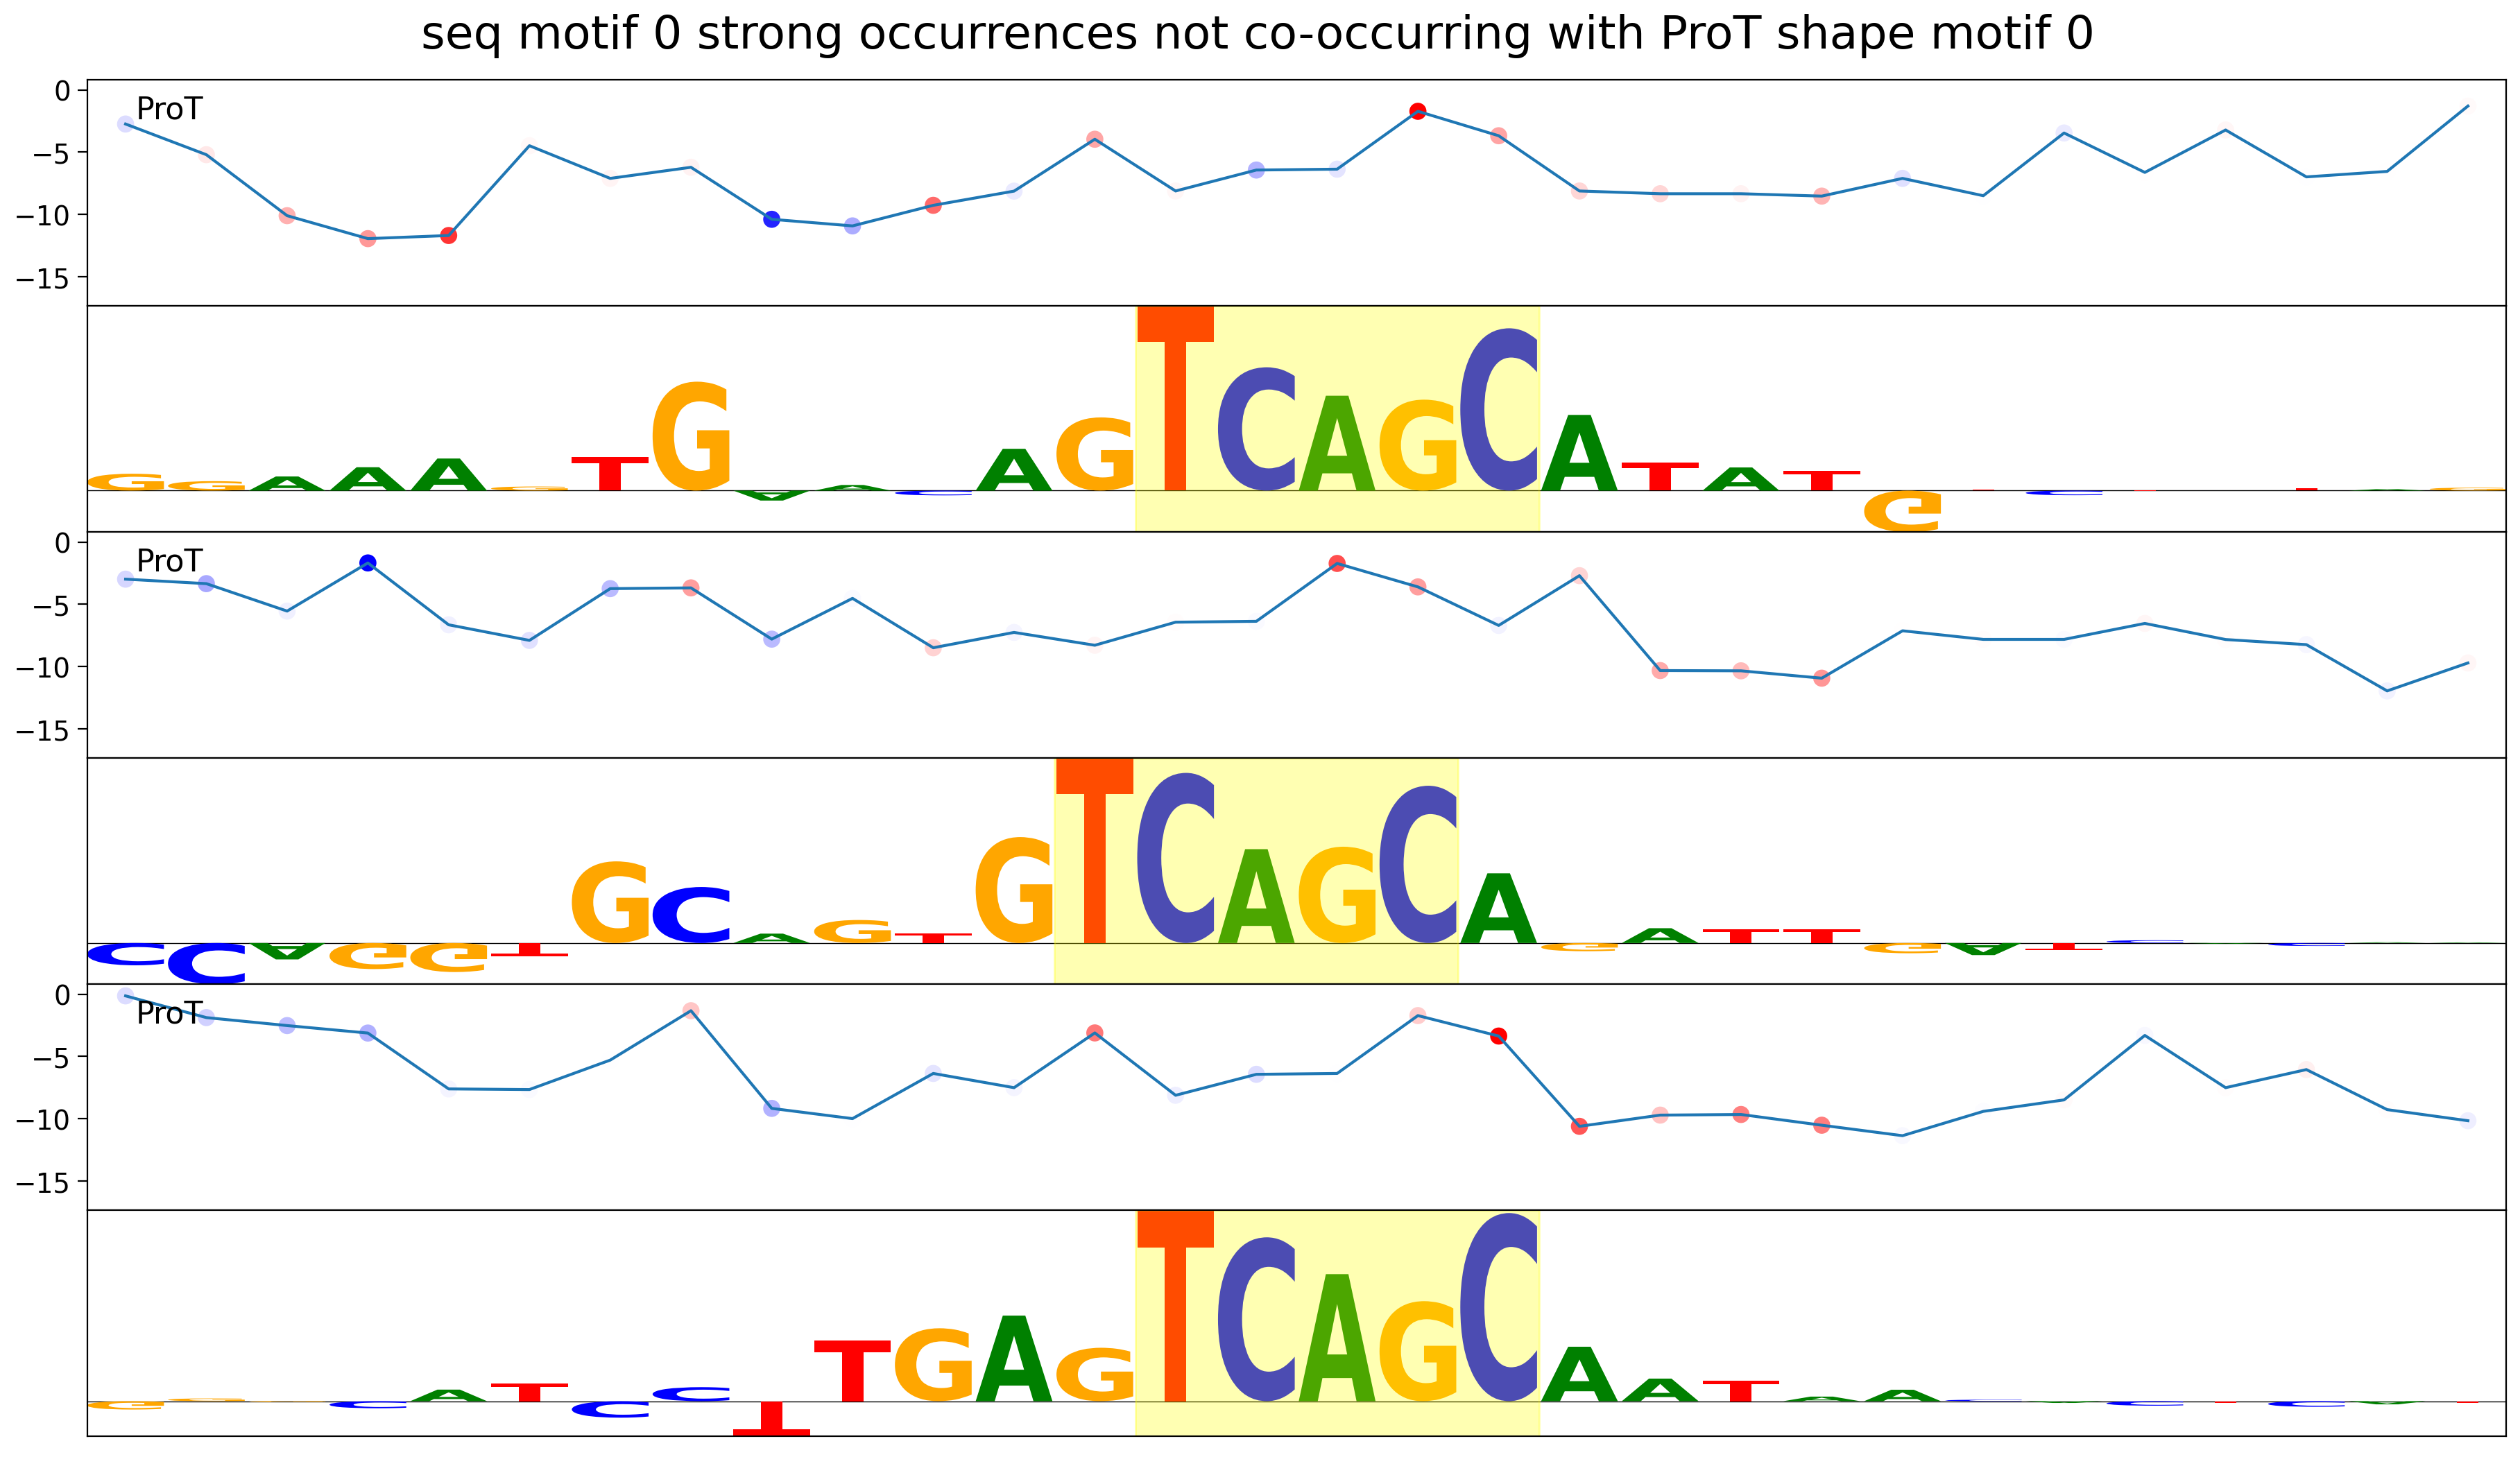

In [20]:
np.random.seed(50)
cooccurring_seq_occs = [pair[0] for pair in strong_seq_pairs]
seq_only_occurrences = [occurrence for occurrence in strong_seq_occurrences
                        if occurrence not in cooccurring_seq_occs]
chosen_inds = np.random.choice(len(seq_only_occurrences), n_ex, replace=False)
fig, axes = plt.subplots(n_ex*2, 1, figsize=(22.5, n_ex*2*2), gridspec_kw={'hspace': 0}, sharex=True, dpi=200)
seq_occurrences_to_plot = [seq_only_occurrences[i] for i in chosen_inds]
for i, occurrence in enumerate(seq_occurrences_to_plot):
    exi, start, end, strand = occurrence
    mid = (start + end) // 2
    interval = (exi, mid - 15, mid + 15, strand)
    
    plot_seqlet(interval, center_encs, center_atts, fi, feats, smin, smax,
                axes[2*i:2*i+2], verbose=False)
    if strand == '+':
        rel_start = start - (mid - 15) - (fi in [1, 4])
        rel_end = end - (mid - 15) - (fi in [1, 4])
    else:
        rel_start = mid + 15 - end
        rel_end = mid + 15 - start
    axes[2*i + 1].axvspan(rel_start - 0.5, rel_end - 0.5, color='yellow', alpha=0.3)
fig.suptitle(f"seq motif {seq_pat_i} strong occurrences not co-occurring with {feat} shape motif {shape_pat_i}",
            fontsize=24)
fig.subplots_adjust(top=0.94)
plt.show()

## Compare binding affinity of co-occurrences and non-co-occurrences
For each sequence motif occurrence, trace it back to the ChIP-seq interval that contained it and retrieve its binding affinity

                        0
coocc_mean     159.834980
noncoocc_mean  117.964594
coocc_n        317.000000
noncoocc_n     119.000000
p_val_greater    0.000003


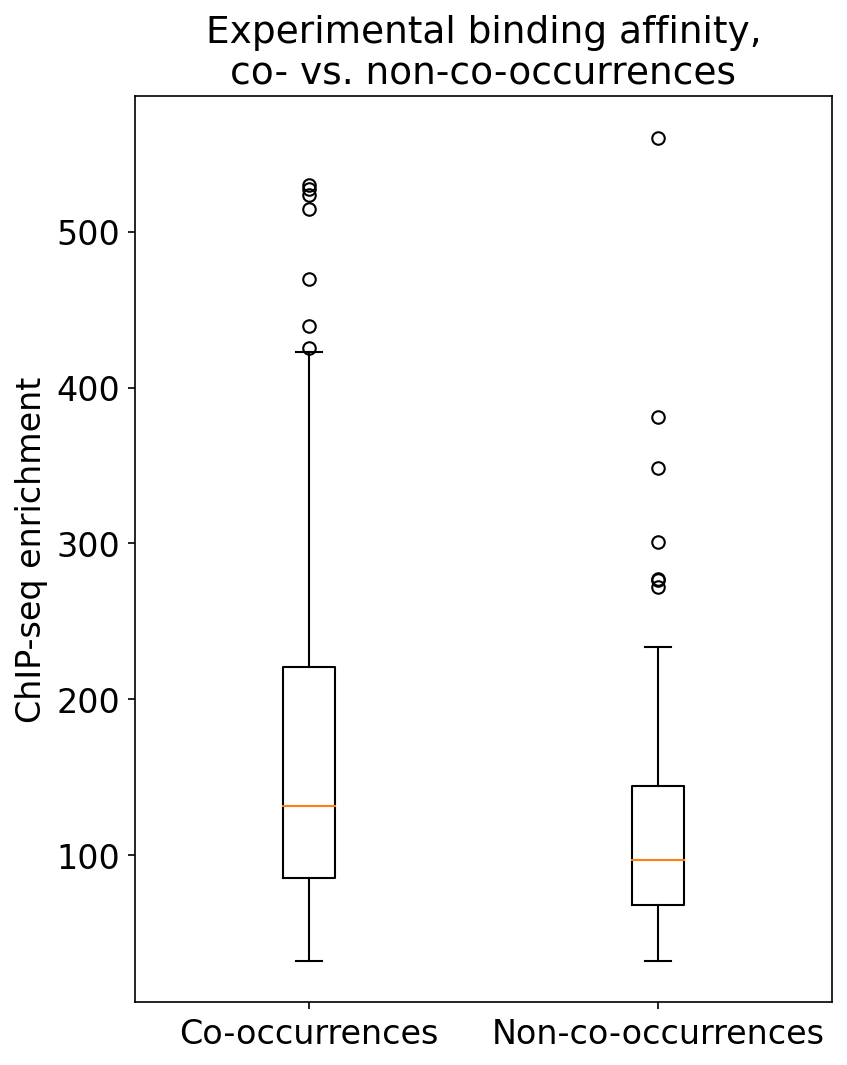

In [21]:
pos_intervals = []
with open(positive_data_path, "r") as f:
    for line in f.readlines():
        chrom, start, end = line.split("\t")[:3]
        pos_intervals.append((chrom, int(start), int(end)))

seq_occurrence_genome_intervals = []
for occurrence in strong_seq_occurrences:
    ex_i, occ_start, occ_end = occurrence[:3]
    chrom, genome_start = pos_intervals[ex_i][0], pos_intervals[ex_i][1]
    seq_occurrence_genome_intervals.append(
        (chrom, occ_start + genome_start + 300, occ_end + genome_start + 300))

def find_contained_intervals(ref_intervals, query_intervals):
    sorted_ref_intervals_by_chrom = {}
    for i, (chrom, start, end) in enumerate(ref_intervals):
        if chrom not in sorted_ref_intervals_by_chrom:
            sorted_ref_intervals_by_chrom[chrom] = []
        sorted_ref_intervals_by_chrom[chrom].append((start, end, i))
    for chrom in sorted_ref_intervals_by_chrom:
        sorted_ref_intervals_by_chrom[chrom] = sorted(sorted_ref_intervals_by_chrom[chrom])
    
    results = []
    for q_chrom, q_start, q_end in query_intervals:
        contained_indices = []
        if q_chrom in sorted_ref_intervals_by_chrom:
            chrom_ref_intervals = sorted_ref_intervals_by_chrom[q_chrom]
            idx_lim = bisect.bisect_right([x[0] for x in chrom_ref_intervals], q_start)
            for idx in range(idx_lim - 1, -1, -1):
                start, end, i = chrom_ref_intervals[idx]
                if end >= q_end:
                    contained_indices.append(i)
                else:
                    break
        results.append(contained_indices)
    return results

contained_intervals = find_contained_intervals(chip_intervals,
                                               seq_occurrence_genome_intervals)

coocc_chip_scores = []
noncoocc_chip_scores = []
for i, containing_inds in enumerate(contained_intervals):
    if len(containing_inds) > 0:
        chip_score = max([chip_df.iloc[ind, 6] for ind in containing_inds])
        occurrence = strong_seq_occurrences[i]
        if occurrence in cooccurring_seq_occs:
            coocc_chip_scores.append(chip_score)
        else:
            noncoocc_chip_scores.append(chip_score)
            
coocc_n = len(coocc_chip_scores)
noncoocc_n = len(noncoocc_chip_scores)

pval = scipy.stats.ttest_ind(coocc_chip_scores, noncoocc_chip_scores, equal_var=False, alternative='greater')[1]

plt.figure(figsize=(6, 8), dpi=150)
plt.boxplot([coocc_chip_scores, noncoocc_chip_scores], labels=['Co-occurrences', 'Non-co-occurrences'])
plt.tick_params(axis='both', labelsize=16)
plt.ylabel("ChIP-seq enrichment", fontsize=16)
coocc_mean = np.mean(coocc_chip_scores)
noncoocc_mean = np.mean(noncoocc_chip_scores)
chip_coocc_vs_noncoocc_df = pd.DataFrame.from_dict({'coocc_mean': coocc_mean, 'noncoocc_mean': noncoocc_mean,
                                         "coocc_n": coocc_n, "noncoocc_n": noncoocc_n,
                                         "p_val_greater": pval}, orient='index')
print(chip_coocc_vs_noncoocc_df)
plt.title("Experimental binding affinity,\nco- vs. non-co-occurrences", fontsize=18)
plt.show()
